In [1]:
!pip install xgboost shap

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("Algerian_forest_fires_dataset.csv")
df.head()


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [11]:
df.columns = df.columns.str.strip()

df.columns


Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes'],
      dtype='object')

In [12]:
df['Classes'] = df['Classes'].str.strip()

df['fire_label'] = df['Classes'].map({
    'fire': 1,
    'not fire': 0
})

df['fire_label'].value_counts()


,count
fire_label,
1.0,137
0.0,106


In [13]:
for col in df.columns:
    if col not in ['Classes']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(inplace=True)


In [14]:
df.drop(columns=['FWI','Classes','day','month','year'], inplace=True)


In [16]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['fire_label'])
y = df['fire_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBClassifier(
        n_estimators=350,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss"
    ))
])

pipeline.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=350, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [18]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9591836734693877
              precision    recall  f1-score   support

         0.0       1.00      0.90      0.95        21
         1.0       0.93      1.00      0.97        28

    accuracy                           0.96        49
   macro avg       0.97      0.95      0.96        49
weighted avg       0.96      0.96      0.96        49



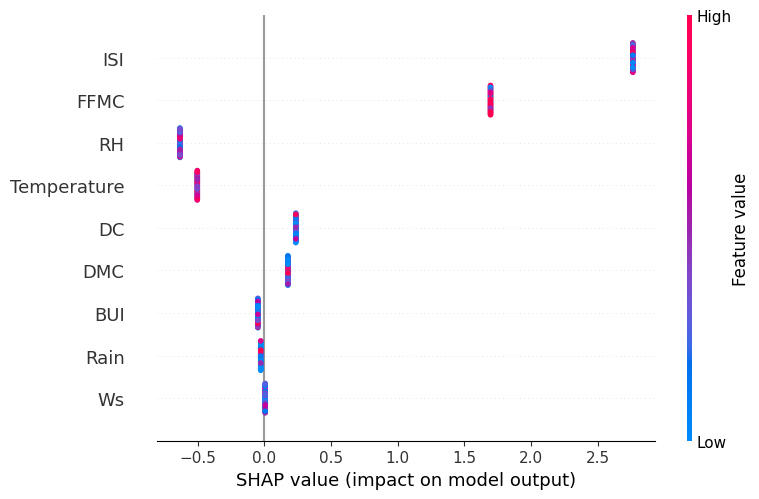

In [19]:
import shap

xgb_model = pipeline.named_steps["model"]
explainer = shap.TreeExplainer(xgb_model)

sample = X_test.iloc[:50]
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample)


In [20]:
import joblib

joblib.dump(pipeline, "risk_pipeline.pkl")
joblib.dump(list(X.columns), "feature_names.pkl")


['feature_names.pkl']